In [2]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [9]:
from pycbc import detector
from pycbc.detector import Detector
ifos = ["H1", "L1", "V1"]
ifo1 = detector.Detector(ifos[0])
ifo2 = detector.Detector(ifos[1])
ifo3 = detector.Detector(ifos[2])
time_diff_12 = ifo1.light_travel_time_to_detector(ifo2)
time_diff_13 = ifo1.light_travel_time_to_detector(ifo3)

In [234]:
N = 1000000
t_gps=uniform(0, 12345678, N)
right_ascension=uniform(0, 2*pi, N)#[0]*N
declination=arcsin(uniform(-1, 1, N))#[0]*N

In [235]:
t_diff12 = ifo1.time_delay_from_detector(ifo2, right_ascension, declination, t_gps)
t_diff13 = ifo1.time_delay_from_detector(ifo3, right_ascension, declination, t_gps)
# t_diff21 = ifo2.time_delay_from_detector(ifo1, right_ascension, declination, t_gps)
# t_diff31 = ifo3.time_delay_from_detector(ifo1, right_ascension, declination, t_gps)
t_diff32 = ifo3.time_delay_from_detector(ifo2, right_ascension, declination, t_gps)
# convert to ms
t_diff12 *= 1000
t_diff13 *= 1000
t_diff21 *= 1000
t_diff31 *= 1000
t_diff32 *= 1000

In [95]:
t_diff21, t_diff12

(array([-3001561.07546573,  9265416.90351315,  6703687.17793594, ...,
         3130285.54268464,  8352360.26621254,  4390424.9450635 ]),
 array([-3.92449801,  3.8727925 ,  2.65804764, ..., -8.56498008,
        -8.72313541, -7.27864107]))

In [47]:
ifo1 = Detector("H1")
ifo2 = Detector("L1")
ifo3 = Detector("V1")

In [48]:
tau_12 = ifo1.light_travel_time_to_detector(ifo2)
tau_13 = ifo1.light_travel_time_to_detector(ifo3)
tau_23 = ifo2.light_travel_time_to_detector(ifo3)
tau_12, tau_13, tau_23

(0.010012846152223925, 0.027287979933844225, 0.026448341016726495)

In [49]:
b, a, c = tau_12, tau_13, tau_23
arccos((a**2 + b**2 - c**2) / (2*a*b))

1.3015216715223716

In [227]:
def angle_between_detectors(tau_12, tau_13, tau_23):
    """Calculate the angle between ifo2 and ifo3 viewed from ifo1.
    
    Parameters
    ----------
    tau_12: float
        Light travel time between ifo1 and ifo2 (arbitrary units).
    tau_13: float
        Light travel time between ifo1 and ifo3 (arbitrary units).
    tau_23: float
        Light travel time between ifo2 and ifo3 (arbitrary units).

    Returns
    -------
    alpha_23: float
        Angle (in radians) between ifo2 and ifo3 viewed from ifo1.
    """
    b, a, c = tau_12, tau_13, tau_23
    alpha_23 = np.arccos((a**2 + b**2 - c**2) / (2*a*b))
    return alpha_23

def check_time_delay_is_physical(
    n2, n3, N2, N3, alpha_23, rounding=True):
    """Check if the delay time between two detector combinations
    is geometrically possible. The units for time are arbritrary 
    but must be consistent. However if using rounding units must be 
    time indices. 
    
    Parameters
    ----------
    n2: float or array
        Delay time between ifo1 and ifo2.
    n3: float or array
        Delay time between ifo1 and ifo2.
    N2: float
        Light travel time between ifo1 and ifo2.
    N3: float
        Light travel time between ifo1 and ifo3.
    alpha_23: float
        Angle (in radians) between ifo2 and ifo3 viewed from ifo1.
    rounding: bool
        If True will include the point just outside the geometrical 
        region in the physical region.
        
    Returns
    cond: bool, or boolean array
        False if delay times are unphysical. 
    """
    N3 = float(N3)
    p = N3 / N2 * cos(alpha_23)
    q = N3 / N2 * sin(alpha_23)
    if rounding:
        # below line ensures we take the dots just outside 
        # the ellipse to be safe and account for rounding
        # FIXME: revise below
        n2_safe = n2 - sign(n2)*0.1
        n3_safe = n3 - sign(n3)*0.1
    # Eq 3.4 for the ellipse from https://arxiv.org/pdf/gr-qc/9509042.pdf
    cond = n3_safe**2 + n2_safe**2*(N3/N2)**2 - 2*p*n2_safe*n3_safe < (q*N2)**2
    return cond

In [96]:
def get_bounds(dt, a=0.010012846152223925*1000, c=0.027287979933844225*1000):
    dt_2 = c * sqrt(1-dt**2/a**2)
    return -dt_2, dt_2

def get_bounds_2(dt, eps=0.01, timing_error=0.0):
    idx = (t_diff12<dt+eps)&(t_diff12>dt-eps)
    dt2 = t_diff13[idx]
    return min(dt2)-timing_error, max(dt2)+timing_error

def get_bounds_3(dt, det_1="H1", det_2="L1", other_det="V1", eps=0.01):
    dt /=1000
    eps /=1000
    ifo1 = Detector(det_1)
    ifo2 = Detector(det_2)
    ifo3 = Detector(other_det)
    tau_12 = ifo1.light_travel_time_to_detector(ifo2)
    tau_13 = ifo1.light_travel_time_to_detector(ifo3)
    tau_23 = ifo2.light_travel_time_to_detector(ifo3)
    theta_min = arccos(((dt+eps) / tau_12)) if dt+eps<tau_12 else arccos(((dt) / tau_12))
    theta_max = arccos(((dt-eps) / tau_12)) if dt-eps>-tau_12 else arccos(((dt) / tau_12))
    alpha_23 = angle_between_dets(det_2, other_det, viewing_det=det_1)
    min_max = (tau_13 * cos(theta_max + alpha_23), tau_13 * cos(theta_min - alpha_23))
    return min(min_max)*1000, max(min_max)*1000
dt = linspace(-10.01, 10.01, 50)
b3 = array([get_bounds_3(i, eps=0.01) for i in dt]).T
fill_between(dt, b3[0], b3[1], alpha=0.2)

In [97]:
dt = linspace(-10.01, 10.01, 50)
b1 = get_bounds(dt)
b2 = array([get_bounds_2(i, eps=0.01) for i in dt]).T
b3 = array([get_bounds_3(i, eps=0.01) for i in dt]).T
fill_between(dt, b3[0], b3[1], alpha=0.2)
# plot(dt, b1[0])
# plot(dt, b2[0])
# plot(dt, b3[0])

α23 which is the angle between lines D1C2 and D1C3.
the value of n3 may vary in between N3 cos(θ + α23) and N3 cos(θ − α23), depending on φ.

In [112]:
dt[0]

-10.01

In [115]:
c

27.287979933844223

0.6826298701298701


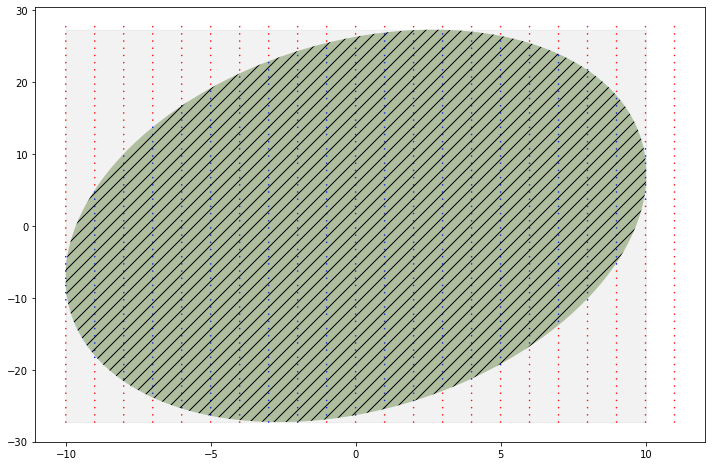

In [230]:
# npts = 100000
# y = random.uniform(-c, c, npts)
spacing = 1
c = 0.027287979933844225*1000
b = 10.01
# dt = linspace(-b, b, int(ceil(10.01*2 / 0.01)))
# b1 = get_bounds(dt)
# b2 = array([get_bounds_2(i, eps=0.01) for i in dt]).T
# b3 = array([get_bounds_3(i, eps=0.01) for i in dt]).T
y, x = meshgrid(arange(-c, c+spacing, spacing), arange(-b, b+spacing, spacing))
x, y = x.flatten(), y.flatten()
# x = random.uniform(-b*1000, b*1000, npts)
# fill_between(dt, b1[0], b1[1], alpha=0.2)
figure(figsize=(array([12, 8])))
fill_between(dt, b2[0], b2[1], alpha=0.2)
fill_between(dt, b3[0], b3[1], alpha=0.2)
fill_between(dt, -c, c, alpha=0.1, color="grey")
alpha_23 = angle_between_dets("L1", "V1", "H1")
cond = check_time_delay_is_physical(
    x, y, b, c, alpha_23)
colors = where(cond, "b", "r")
print(sum(cond) / len(cond))
scatter(x, y, marker="o", c=colors, s=0.3)
fill_between(dt, b2[0], b2[1], alpha=0.2, hatch="//")

0.6655844155844156


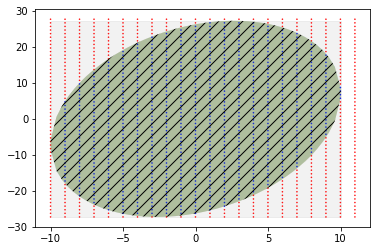

In [183]:
# fill_between(dt, b1[0], b1[1], alpha=0.2)
fill_between(dt, b2[0], b2[1], alpha=0.2)
fill_between(dt, b3[0], b3[1], alpha=0.2)
c = 0.027287979933844225*1000
fill_between(dt, -c, c, alpha=0.1, color="grey")
alpha_23 = angle_between_dets("L1", "V1", "H1")
cond = check_time_delay_is_physical(
    x, y, b*1000, c, alpha_23)
colors = where(cond, "b", "r")
print(sum(cond) / len(cond))
scatter(x, y, marker="o", c=colors, s=0.3)
fill_between(dt, b2[0], b2[1], alpha=0.2, hatch="//")

In [138]:
array([0.1]+[0.4]*99)

array([0.1, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4])

In [31]:
21, 84, 74

(21, 84, 74)

In [32]:
a, b, c = tau_12, tau_23, tau_13
degrees(arccos((a**2 + b**2 - c**2) / (2*a*b)))

84.02448825542298

In [33]:
alpha_LV = radians(84.02448825542298)
alpha_HV = radians(74.57169872304416)
alpha_HL = radians(21.40381302153286)
alpha_LV, alpha_HV, alpha_HL

(1.4665039723604372, 1.3015216715223716, 0.37356700970698437)

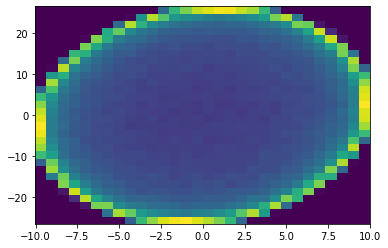

In [236]:
hist2d(t_diff12, t_diff32, bins=30);

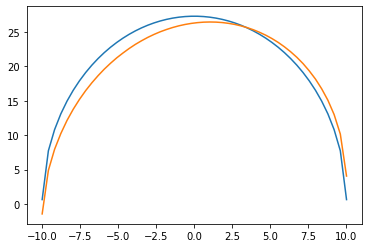

In [35]:
plot(dt, b1[1])
plot(dt, b2[1])

In [36]:
get_bounds(9)

(-11.959393399249803, 11.959393399249803)

In [37]:
get_bounds_2(9)

(-9.086972127826797, 14.051373655717667)

In [38]:
ii = where(t_diff32 == -18.09383435236984)
ii

(array([], dtype=int64),)

In [39]:
t_diff21[ii], right_ascension[ii], declination[ii]

(array([], dtype=float64), array([], dtype=float64), array([], dtype=float64))

1036


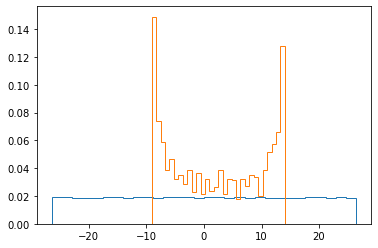

In [40]:
hist(t_diff32, **hist_kwargs);
eps = 0.01
dt = 9
idx = (t_diff12<dt+eps)&(t_diff12>dt-eps)
print(sum(idx))
hist(t_diff32[idx], **hist_kwargs);

1036


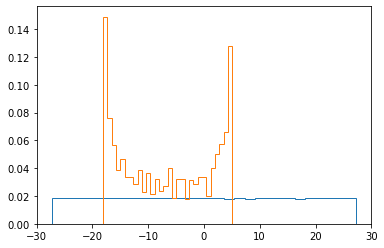

In [41]:
hist(t_diff31, **hist_kwargs);
eps = 0.01
dt = 9
idx = (t_diff12<dt+eps)&(t_diff12>dt-eps)
print(sum(idx))
hist(t_diff31[idx], **hist_kwargs);

In [42]:
min(abs(t_diff32[idx]))

0.000841903702135642

In [43]:
len(t_diff32[idx])

1036

### Search arrays

In [9]:
N=int(2e5)
t1 = chisquare(4,N)
t2 = chisquare(4,N)
t3 = chisquare(4,N)
t2_coinc_window = int(83 / 2.)
t3_coinc_window = int(230 / 2.)

In [10]:
from numba.typed import List
from numba import njit

### optimising masked arrays

In [46]:
idx = [[[
    (i,j,k)
    for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
        for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
            for i in range(N)]

KeyboardInterrupt: 

In [ ]:
_mask = zeros(N)[_idx] = ones(N)[_idx]

In [ ]:
_mask = zeros(N)
_mask[_idx] = 1

In [824]:
sum(_mask), len(_mask)

(78633.0, 200000)

In [844]:
_idx = choice(range(N), size=int(N/2.0), replace=False)
_mask = zeros(N)
_mask[_idx] = 1

In [847]:
sum(_mask), len(_mask)

(100000.0, 200000)

In [11]:
N=2223048
t1 = uniform(0,1,N)
t2 = uniform(0,1,N)
t3 = uniform(0,0.6,N)

_size = 2000 #int(N/2.0)
_idx = choice(range(N), size=_size, replace=False)
_mask = zeros(N, dtype=bool)
_mask[_idx] = 1

# _idx = _mask

def _t0():
    out = t1 + t2
    return out[_idx] 

@njit
def _t1():
    out = zeros_like(t1)
    out[_idx] = t1[_idx] + t2[_idx]
    return out[_idx]

@njit
def _t2():
    out = t1 + t2
    return out[_idx] 

def _t3():
    out = zeros_like(t1)
    out[_idx] = t1[_idx] + t2[_idx]
    return out[_idx]

@njit
def _t4():
    out = t1[_idx] + t2[_idx]
    return out

def _t5():
    out = t1[_idx] + t2[_idx]
    return out

# @njit
def _t6():
    out = zeros_like(t1)
    out = add(t1, t2, out, where=_mask)
    return out

In [915]:
_o = _t6()

In [916]:
_o = _t0()
_o = _t1()
_o = _t2()
_o = _t3()
_o = _t4()
_o = _t5()
_o = _t6()

In [917]:
import time

In [918]:
_n_tests = 1000
_ts_t0 = []
for i in range(_n_tests):
    bf = time.time()
    out = _t1()
    af = time.time()
    _ts_t0.append((af - bf)*1000)
_ts_t1 = []
for i in range(_n_tests):
    bf = time.time()
    out = _t1()
    af = time.time()
    _ts_t1.append((af - bf)*1000)
_ts_t2 = []
for i in range(_n_tests):
    bf = time.time()
    out = _t2()
    af = time.time()
    _ts_t2.append((af - bf)*1000)
_ts_t3 = []
for i in range(_n_tests):
    bf = time.time()
    out = _t3()
    af = time.time()
    _ts_t3.append((af - bf)*1000)
_ts_t4 = []
for i in range(_n_tests):
    bf = time.time()
    out = _t4()
    af = time.time()
    _ts_t4.append((af - bf)*1000)
_ts_t5 = []
for i in range(_n_tests):
    bf = time.time()
    out = _t5()
    af = time.time()
    _ts_t5.append((af - bf)*1000)
_ts_t6 = []
for i in range(_n_tests):
    bf = time.time()
    out = _t6()
    af = time.time()
    _ts_t6.append((af - bf)*1000)

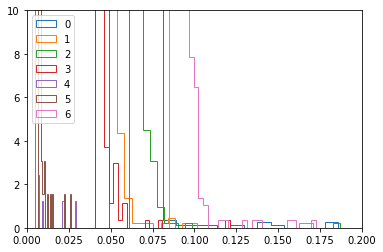

In [924]:
for i, _a in enumerate([_ts_t0, _ts_t1, _ts_t2, _ts_t3, _ts_t4, _ts_t5, _ts_t6]):
    hist(_a, bins=30, histtype="step", density=True, label=i)
ylim(0,10)
xlim(0, 0.2)
legend()

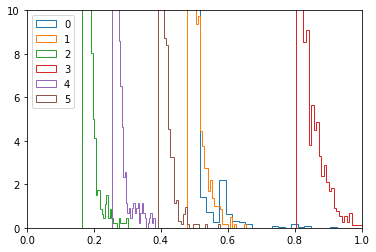

In [862]:
for i, _a in enumerate([_ts_t0, _ts_t1, _ts_t2, _ts_t3, _ts_t4, _ts_t5]):
    hist(_a, bins=30, histtype="step", density=True, label=i)
ylim(0,10)
xlim(0,1)
legend()

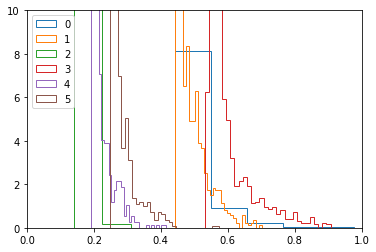

In [867]:
for i, _a in enumerate([_ts_t0, _ts_t1, _ts_t2, _ts_t3, _ts_t4, _ts_t5]):
    hist(_a, bins=30, histtype="step", density=True, label=i)
ylim(0,10)
xlim(0,1)
legend()

In [928]:
83*230

19090

In [22]:
_ = add.outer([1,2,3], [0,1,3])#, where=[[1,0,0], [0,0,0], [0,0,0]])
print(_)
add.outer(_, [2,1,2])

[[1 2 4]
 [2 3 5]
 [3 4 6]]


array([[[3, 2, 3],
        [4, 3, 4],
        [6, 5, 6]],

       [[4, 3, 4],
        [5, 4, 5],
        [7, 6, 7]],

       [[5, 4, 5],
        [6, 5, 6],
        [8, 7, 8]]])

In [962]:
N=1000 #int(2e3)
t1 = chisquare(4,N)
t2 = chisquare(4,N)
t3 = chisquare(4,N)

In [963]:
temp = add.outer(add.outer(t1, t2), t3)

In [964]:
len(temp.flatten())

1000000000

In [ ]:
add.outer()

In [29]:
array([[1,3,4], [1,2]], dtype=object).flatten()

array([list([1, 3, 4]), list([1, 2])], dtype=object)

In [47]:
b = array([1.0])
b.nbytes, b.dtype

(8, dtype('float64'))

In [49]:
8 * 2e6*230 / 1e6

3680.0

In [50]:
8 * 4e8 / 1e6

3200.0

In [58]:
N=int(2e6)
t1 = chisquare(4,N)
t2 = chisquare(4,N)
t3 = chisquare(4,N)

In [59]:
sum(t1>4**2)

5992

### optimising three det sum combinations|

In [114]:

@njit
def three_det_sum(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    N = len(t1)
    temp = [[[
        t1[i] + t2[j] + t3[k]
        for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
            for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
                for i in range(N)]
    return temp


@njit
def three_det_sum_cond(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    N = len(t1)
    temp = [[[
        t1[i] + t2[j] + t3[k] if ((t1[i]>0.9)|(t2[j]>0.9)|(t3[k]>0.8)) else 0
        for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
            for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
                for i in range(N)]
    return temp

# @njit
def three_det_sum_outer(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    
    t = [add.outer(
        add.outer(t1, t2[max(i-t2_coinc_window, 0):min(N, i+t2_coinc_window+1)]), 
        t3[max(i-t3_coinc_window, 0):min(N, i+t3_coinc_window+1)])
         for i in range(N)]
    return t

@njit
def get_idxs(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    N = len(t1)
    idx = [[[
    (i,j,k)
    for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
        for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
            for i in range(N)]

# %time temp = three_det_sum(t1, t2, t3, t2_coinc_window, t3_coinc_window)

In [124]:
# @njit
def three_det_sum_t1cond(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    idx = flatnonzero(t1 > 4**2)
    print(len(idx))
    N = len(t1)
    temp = [[[
        t1[i] + t2[j] + t3[k]
        for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
            for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
                for i in idx]
    return temp

# @njit
def three_det_sum_t1cond_opt(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    idx = flatnonzero(t1 > 4**2)
    print(len(idx))
    N = len(t1)
    multi_trigs = []
    multi_trigs_idx = []
    for i in idx:
        for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1)):
            ks = range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))
            temp = array([
                t1[i] + t2[j] + t3[k] for k in ks
            ])
            thresh_idx = flatnonzero(temp > 7**2)
            if thresh_idx.size>0:
                multi_trigs.extend(temp[thresh_idx])
                multi_trigs_idx.extend([(i,j,ks[ti]) for ti in thresh_idx])
    return multi_trigs

In [125]:
%time temp = three_det_sum_t1cond_opt(t1, t2, t3, t2_coinc_window, t3_coinc_window)

583
CPU times: user 6.6 s, sys: 39 ms, total: 6.64 s
Wall time: 6.66 s


In [126]:
sqrt(temp)

array([7.06646743, 7.07112306, 7.00739483, ..., 7.05246188, 7.23700546,
       7.09714583])

In [133]:
len(temp) * 8

23048

In [129]:
array(temp).nbytes / 1000

23.048

In [97]:
%time temp = three_det_sum_t1cond(t1, t2, t3, t2_coinc_window, t3_coinc_window)

639
CPU times: user 1.52 s, sys: 38.8 ms, total: 1.56 s
Wall time: 1.57 s


In [70]:
from pycbc import pnutils

In [86]:
from pycbc import conversions

In [94]:
total_mass=100
for q in (1,5,10,20):
    m1, m2 = conversions.mass1_from_mtotal_q(total_mass, q), conversions.mass2_from_mtotal_q(total_mass, q)
    print(m1,m2, pnutils.get_final_freq("EOBNRv2", m1, m2, 0, 0), pnutils.f_FRD(m1, m2))

50.0 50.0 178.89872810535354 187.67122644791206
83.33333333333333 16.666666666666668 145.9242550510935 153.4042939887386
90.9090909090909 9.090909090909092 134.40090497993978 138.7569076884172
95.23809523809524 4.761904761904762 127.84601560533567 129.79077930826293


In [97]:
pnutils.get_final_freq("EOBNRv2", 10, 10, 0, 0)

array(894.49364053)

In [93]:
pnutils.f_FRD(100, 100), pnutils.f_ERD(200)

(93.83561322395603, 96.41001980562966)

In [26]:
# %time temp = three_det_sum_outer(t1, t2, t3, t2_coinc_window, t3_coinc_window)

KeyboardInterrupt: 

In [98]:
@njit
def three_det_sum_jit(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    N = len(t1)
    temp = [[[
        t1[i] + t2[j] + t3[k]
        for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
            for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
                for i in range(N)]
    return temp

def three_det_sum(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    N = len(t1)
    temp = [[[
        t1[i] + t2[j] + t3[k]
        for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
            for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
                for i in range(N)]
    return temp

In [101]:
%time temp = three_det_sum(t1, t2, t3, t2_coinc_window, t3_coinc_window)

CPU times: user 434 ms, sys: 2.73 ms, total: 437 ms
Wall time: 438 ms


In [113]:
%time temp = three_det_sum_jit(t1, t2, t3, t2_coinc_window, t3_coinc_window)

CPU times: user 38 ms, sys: 3.63 ms, total: 41.6 ms
Wall time: 42.1 ms


In [813]:
%time temp = three_det_sum_cond(t1, t2, t3, t2_coinc_window, t3_coinc_window)

CPU times: user 250 ms, sys: 4.42 ms, total: 254 ms
Wall time: 254 ms


In [782]:
tmp_idx = get_idxs(t1, t2, t3, t2_coinc_window, t3_coinc_window)

In [794]:
%time tmp_idx = get_idxs(t1, t2, t3, t2_coinc_window, t3_coinc_window)

CPU times: user 72 µs, sys: 2 µs, total: 74 µs
Wall time: 82 µs


In [798]:
_tt = array(temp, dtype=object)

In [801]:
_tt = _tt.flatten()

In [804]:
_tt

array([list([[1.7322233225668937, 1.208162525699994, 1.609775134201987], [2.0697873367486332, 1.5457265398817333, 1.9473391483837263]]),
       list([[1.035727416805567, 0.5116666199386671, 0.9132792284406601, 0.7302031046705705], [1.373291430987306, 0.8492306341204063, 1.2508432426223994, 1.0677671188523097], [1.1349650458195204, 0.6109042489526205, 1.0125168574546135, 0.8294407336845239]]),
       list([[2.075846694262629, 1.551785897395729, 1.9533985058977221, 1.7703223821276324, 1.6764321154873687], [1.8375203090948429, 1.313459512227943, 1.7150721207299362, 1.5319959969598465, 1.4381057303195828], [2.391780356774328, 1.867719559907428, 2.269332168409421, 2.0862560446393315, 1.9923657779990678]]),
       list([[1.205545731718078, 1.607158340220071, 1.4240822164499813, 1.3301919498097177], [1.7598057793975628, 2.161418387899556, 1.9783422641294661, 1.8844519974892022], [1.7461094224716491, 2.1477220309736422, 1.9646459072035525, 1.8707556405632886]]),
       list([[1.762290396338887

In [49]:
N=100 #int(2e3)
t1 = chisquare(4,N)
t2 = chisquare(4,N)
t3 = chisquare(4,N)

In [55]:
def three_det_sum(t1, t2, t3, t2_coinc_window, t3_coinc_window):
    N = len(t1)
    temp = array([[[
        t1[i] + t2[j] + t3[k]
        for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
            for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
                for i in range(N)])
    return temp
%time temp = three_det_sum(t1, t2, t3, t2_coinc_window, t3_coinc_window)

CPU times: user 456 ms, sys: 2.4 ms, total: 458 ms
Wall time: 457 ms


/var/folders/2n/44xg31f92bd49rgkf9bsy4j80000gq/T/ipykernel_68649/716908544.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  temp = array([[[


In [367]:
for i in range(N):
    print(list(range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))))

[0, 1, 2]
[0, 1, 2, 3]
[0, 1, 2, 3, 4]
[1, 2, 3, 4, 5]
[2, 3, 4, 5]
[3, 4, 5]


In [361]:
print(t1)

[0.15374981 0.04750711 0.38221551 0.12908947 0.12783865 0.52528635]


In [371]:
N = len(t1)
temp = [[[
    t1[i] + t2[j] + t3[k]
    for k in range(max(i-t3_coinc_window, 0), min(N, i+t3_coinc_window+1))]
        for j in range(max(i-t2_coinc_window, 0), min(N, i+t2_coinc_window+1))]
            for i in range(N)]

In [354]:
t2[5]

0.14028871004853083

In [372]:
temp

[[[0.7990197784641603, 0.9971590590291357, 1.024357910748575],
  [1.1897585795270924, 1.387897860092068, 1.415096711811507]],
 [[0.7627504197337673,
   0.9608897002987429,
   0.9880885520181819,
   1.145450599058935],
  [1.1534892207966996,
   1.3516285013616751,
   1.3788273530811141,
   1.5361894001218672],
  [0.86188949856624,
   1.0600287791312155,
   1.0872276308506545,
   1.2445896778914076]],
 [[1.474819207489999,
   1.6729584880549746,
   1.7001573397744136,
   1.8575193868151667,
   1.6636547276863625],
  [1.1832194852595395,
   1.381358765824515,
   1.408557617543954,
   1.565919664584707,
   1.3720550054559029],
  [1.5594632256267142,
   1.7576025061916898,
   1.7848013579111288,
   1.9421634049518819,
   1.7482987458230776]],
 [[1.3257544902745102,
   1.3529533419939492,
   1.5103153890347023,
   1.316450729905898,
   1.5606409799993046],
  [1.701998230641685,
   1.729197082361124,
   1.886559129401877,
   1.6926944702730728,
   1.9368847203664794],
  [1.707957342946673,
  

In [53]:
id(t1), id(t1[1]), id(t1)

(140396457007904, 140396988132432, 140396457007904)

In [60]:
ii = slice(-1,4)

In [62]:
from ligo.segments import segment

In [169]:
t1*array([t2]*10)[t2_perms]

IndexError: arrays used as indices must be of integer (or boolean) type

In [172]:
type(t2_perms[0])

list

[0, 1, 2, None]

In [170]:
t2_perms

array([list([0, 1, 2]), list([0, 1, 2, 3]), list([0, 1, 2, 3, 4]),
       list([1, 2, 3, 4, 5]), list([2, 3, 4, 5, 6]),
       list([3, 4, 5, 6, 7]), list([4, 5, 6, 7, 8]),
       list([5, 6, 7, 8, 9]), list([6, 7, 8, 9]), list([7, 8, 9])],
      dtype=object)

In [166]:
t2_perms = array([
    [0,1,2],
    [0,1,2,3],
    [0,1,2,3,4],
    [1,2,3,4,5],
    [2,3,4,5,6],
    [3,4,5,6,7],
    [4,5,6,7,8],
    [5,6,7,8,9],
    [6,7,8,9],
    [7,8,9],
])
t3_perms = array([
    [0,1,2,3], 
    [0,1,2,3,4],
    [0,1,2,3,4,5],
    [0,1,2,3,4,5,6],
    [1,2,3,4,5,6,7],
    [2,3,4,5,6,7,8],
    [3,4,5,6,7,8,9],
    [4,5,6,7,8,9],
    [5,6,7,8,9],
    [6,7,8,9],
])
t3_perms_physical = array(
    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4],#
        [],
        [],
        [],
        [],
        [],
        [],
        [],
    ],
    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5], #
        ,
        ,
        ,
        ,
        ,
        ,
    ],

    [
        [1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        ,
        ,
        ,
        ,
        ,
    ],

    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        [2,3,4,5,6,7,8],
        [3,4,5,6,7,8,9],
        [4,5,6,7,8,9],
        [5,6,7,8,9],
        [6,7,8,9],
    ],

    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        [2,3,4,5,6,7,8],
        [3,4,5,6,7,8,9],
        [4,5,6,7,8,9],
        [5,6,7,8,9],
        [6,7,8,9],
    ],

    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        [2,3,4,5,6,7,8],
        [3,4,5,6,7,8,9],
        [4,5,6,7,8,9],
        [5,6,7,8,9],
        [6,7,8,9],
    ],

    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        [2,3,4,5,6,7,8],
        [3,4,5,6,7,8,9],
        [4,5,6,7,8,9],
        [5,6,7,8,9],
        [6,7,8,9],
    ],

    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        [2,3,4,5,6,7,8],
        [3,4,5,6,7,8,9],
        [4,5,6,7,8,9],
        [5,6,7,8,9],
        [6,7,8,9],
    ],

    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        [2,3,4,5,6,7,8],
        [3,4,5,6,7,8,9],
        [4,5,6,7,8,9],
        [5,6,7,8,9],
        [6,7,8,9],
    ],

    [
        [0,1,2,3], 
        [0,1,2,3,4],
        [0,1,2,3,4,5],
        [0,1,2,3,4,5,6],
        [1,2,3,4,5,6,7],
        [2,3,4,5,6,7,8],
        [3,4,5,6,7,8,9],
        [4,5,6,7,8,9],
        [5,6,7,8,9],
        [6,7,8,9],
    ],
)

/var/folders/2n/44xg31f92bd49rgkf9bsy4j80000gq/T/ipykernel_18787/3937878340.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  t2_perms = array([
/var/folders/2n/44xg31f92bd49rgkf9bsy4j80000gq/T/ipykernel_18787/3937878340.py:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  t3_perms = array([
